In [ ]:
#!pip install opencv-python==4.6.0.66
#!pip install mediapipe
#!pip install numpy==1.22.3

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import time

## Identificação dos olhos

In [ ]:
mp_draw = mp.solutions.drawing_utils
mp_face_mesh = mp.solutions.face_mesh
mp_drawing_styles = mp.solutions.drawing_styles

Eye Aspect Ratio (EAR) é um método para reconhecer se os olhos estão abertos ou fechados calculando a distância euclidiana entre os pontos dos olhos

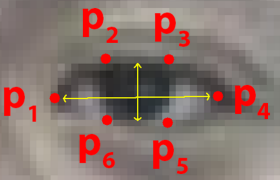

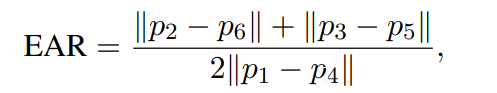

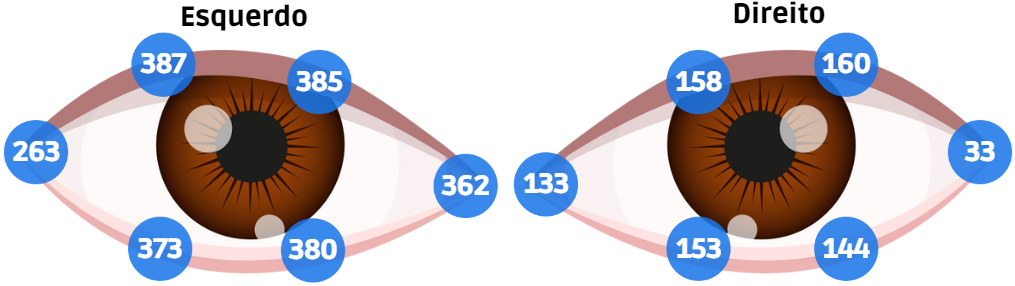

Exemplo de cálculo

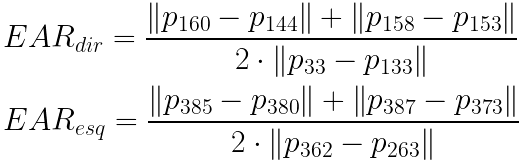

In [ ]:
p_olho_esq = [385, 380, 387, 373, 362, 263]
p_olho_dir = [160, 144, 158, 153, 33, 133]

p_olhos = p_olho_esq + p_olho_dir
p_olhos

[385, 380, 387, 373, 362, 263, 160, 144, 158, 153, 33, 133]

In [ ]:
def calculo_ear(face, p_olho_dir, p_olho_esq):
    try:
        face = np.array([[coord.x, coord.y] for coord in face])
        face_esq = face[p_olho_esq,:]
        face_dir = face[p_olho_dir,:]

        ear_esq = (np.linalg.norm(face_esq[0] - face_esq[1]) + np.linalg.norm(face_esq[2] - face_esq[3]) / (2 * np.linalg.norm(face_esq[4] - face_esq[5])))
        ear_dir = (np.linalg.norm(face_dir[0] - face_dir[1]) + np.linalg.norm(face_dir[2] - face_dir[3]) / (2 * np.linalg.norm(face_dir[4] - face_dir[5])))
    except:
        ear_esq = 0.0
        ear_dir = 0.0

    media_ear = (ear_esq + ear_dir) / 2
    return media_ear


In [ ]:
ear_limiar = 0.14
sleeping = 0

cap = cv2.VideoCapture(0)

with mp_face_mesh.FaceMesh(min_detection_confidence=0.5, min_tracking_confidence=0.5, refine_landmarks=True) as facemesh:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("Frame vazio")
            continue

        comprimento, largura, _ = frame.shape
        frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        output_facemesh = facemesh.process(frame)
        frame = cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)

        try:
            for face_landmarks in output_facemesh.multi_face_landmarks:
                mp_draw.draw_landmarks(frame, face_landmarks, mp_face_mesh.FACEMESH_CONTOURS,
                                    mp_draw.DrawingSpec(color=(250, 155, 105), thickness=1, circle_radius=1),
                                    mp_draw.DrawingSpec(color=(255, 0, 50), thickness=1, circle_radius=1))

                #mp_draw.draw_landmarks(frame, face_landmarks, mp_face_mesh.FACEMESH_CONTOURS,
                #                    landmark_drawing_spec=None,
                #                    connection_drawing_spec = mp_drawing_styles.get_default_face_mesh_contours_style())

                face = face_landmarks.landmark
                for id_coord, coord_xyz in enumerate(face):
                    if id_coord in p_olhos:
                        coord_cv = mp_draw._normalized_to_pixel_coordinates(coord_xyz.x,
                                                                               coord_xyz.y,
                                                                               largura, comprimento)
                        cv2.circle(frame, coord_cv, 2, (0, 0, 255), -1)

                ear = calculo_ear(face, p_olho_dir, p_olho_esq)
                cv2.rectangle(frame, (0,1), (190, 80), (58, 55, 55), -1)
                cv2.putText(frame, f'EAR: {ear:.2f}', (1, 24), cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (100, 50, 200), 2)

                if ear < ear_limiar:
                    t_init = time.time() if sleeping == 0 else t_init
                    sleeping = 1
                if sleeping == 1 and ear >= ear_limiar:
                    sleeping = 0
                t_final = time.time()

                tempo = (t_final - t_init) if sleeping == 1 else 0
                cv2.putText(frame, f'Tempo: {tempo:.3f}',
                            (1, 50), cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (100, 50, 200), 2)

                if tempo>=1.5:
                    cv2.rectangle(frame, (30, 400), (610, 452), (109, 233, 219), -1)
                    cv2.putText(frame, f"Muito tempo com olhos fechados!", (80, 435),
                                    cv2.FONT_HERSHEY_DUPLEX,
                                    0.85, (58,58,55), 1)

        except:
            pass

        cv2.imshow("Camera", frame)
        if cv2.waitKey(10) & 0xFF ==ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

In [ ]:
output_facemesh.multi_face_landmarks

[landmark {
   x: 0.46355167031288147
   y: 0.6747617125511169
   z: -0.025819770991802216
 }
 landmark {
   x: 0.458590567111969
   y: 0.620389997959137
   z: -0.05022495239973068
 }
 landmark {
   x: 0.4588032364845276
   y: 0.6344754099845886
   z: -0.02674190327525139
 }
 landmark {
   x: 0.4449733793735504
   y: 0.5786207318305969
   z: -0.03830332309007645
 }
 landmark {
   x: 0.4571611285209656
   y: 0.6065474152565002
   z: -0.05338328704237938
 }
 landmark {
   x: 0.45483383536338806
   y: 0.5889725685119629
   z: -0.04977241903543472
 }
 landmark {
   x: 0.448787659406662
   y: 0.5481263995170593
   z: -0.0254531130194664
 }
 landmark {
   x: 0.3819487988948822
   y: 0.5620201230049133
   z: 0.009369978681206703
 }
 landmark {
   x: 0.44513335824012756
   y: 0.5232129096984863
   z: -0.019767601042985916
 }
 landmark {
   x: 0.44307631254196167
   y: 0.5069912672042847
   z: -0.02166483737528324
 }
 landmark {
   x: 0.43440690636634827
   y: 0.4411185383796692
   z: -0.010815

In [ ]:
for face_landmarks in output_facemesh.multi_face_landmarks:
    face = face_landmarks
    for id_coord, coord_xyz in enumerate(face_landmarks.landmark):
        print(id_coord, coord_xyz.x, coord_xyz.y, coord_xyz.z)

0 0.46355167031288147 0.6747617125511169 -0.025819770991802216
1 0.458590567111969 0.620389997959137 -0.05022495239973068
2 0.4588032364845276 0.6344754099845886 -0.02674190327525139
3 0.4449733793735504 0.5786207318305969 -0.03830332309007645
4 0.4571611285209656 0.6065474152565002 -0.05338328704237938
5 0.45483383536338806 0.5889725685119629 -0.04977241903543472
6 0.448787659406662 0.5481263995170593 -0.0254531130194664
7 0.3819487988948822 0.5620201230049133 0.009369978681206703
8 0.44513335824012756 0.5232129096984863 -0.019767601042985916
9 0.44307631254196167 0.5069912672042847 -0.02166483737528324
10 0.43440690636634827 0.4411185383796692 -0.010815818794071674
11 0.4641057550907135 0.6812122464179993 -0.024428782984614372
12 0.4644136428833008 0.6874277591705322 -0.021418465301394463
13 0.4644859731197357 0.6915023922920227 -0.016798943281173706
14 0.4642874300479889 0.6916236877441406 -0.015325670130550861
15 0.46516600251197815 0.6986066102981567 -0.016551490873098373
16 0.465

## Identificação da boca

Exemplo de cálculo do Mouth Opening Ratio (MOR)

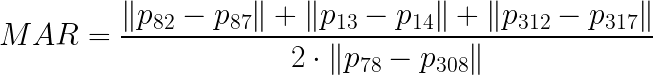

Pontos da boca

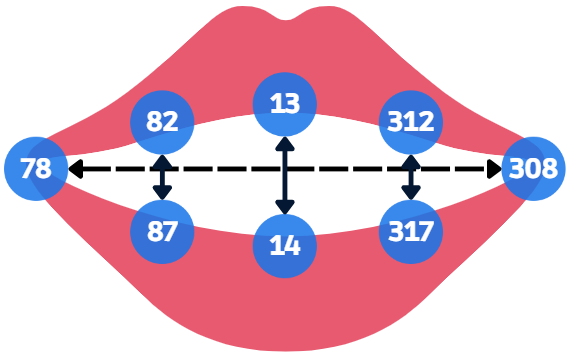

O cálculo é feito com as distâncias euclidianas entre os pontos dos lábios superior e inferior e a soma deles é dividida por duas vezes a distância euclidiana dos pontos das extremidades.

In [ ]:
p_boca = [82, 87, 13, 14, 312, 317, 78, 308]

In [ ]:
def calculo_mar(face, p_boca):
    try:
        face = np.array([[coord.x, coord.y] for coord in face])
        face_boca = face[p_boca,:]
        mar = (np.linalg.norm(face_boca[0] - face_boca[1]) + np.linalg.norm(face_boca[2] - face_boca[3]) + np.linalg.norm(face_boca[4] - face_boca[5]) / (2 * np.linalg.norm(face_boca[6] - face_boca[7])))
    except:
        mar = 0.0
    return mar

In [ ]:
ear_limiar = 0.14
mar_limiar = 0.15
sleeping = 0
open_mouth = 0
blink_count = 0
c_time = 0
c_temp = 0
list_count = []

t_blinks = time.time()

cap = cv2.VideoCapture(0)

with mp_face_mesh.FaceMesh(min_detection_confidence=0.5, min_tracking_confidence=0.5, refine_landmarks=True) as facemesh:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print("Frame vazio")
            continue

        comprimento, largura, _ = frame.shape
        frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
        output_facemesh = facemesh.process(frame)
        frame = cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)

        try:
            for face_landmarks in output_facemesh.multi_face_landmarks:
                mp_draw.draw_landmarks(frame, face_landmarks, mp_face_mesh.FACEMESH_CONTOURS,
                                    mp_draw.DrawingSpec(color=(250, 155, 105), thickness=1, circle_radius=1),
                                    mp_draw.DrawingSpec(color=(255, 0, 50), thickness=1, circle_radius=1))

                #mp_draw.draw_landmarks(frame, face_landmarks, mp_face_mesh.FACEMESH_CONTOURS,
                #                    landmark_drawing_spec=None,
                #                    connection_drawing_spec = mp_drawing_styles.get_default_face_mesh_contours_style())

                face = face_landmarks.landmark
                for id_coord, coord_xyz in enumerate(face):
                    if id_coord in p_olhos:
                        coord_cv = mp_draw._normalized_to_pixel_coordinates(coord_xyz.x,
                                                                               coord_xyz.y,
                                                                               largura, comprimento)
                        cv2.circle(frame, coord_cv, 2, (0, 0, 255), -1)
                    if id_coord in p_boca:
                        coord_cv = mp_draw._normalized_to_pixel_coordinates(coord_xyz.x,coord_xyz.y, largura, comprimento)
                        cv2.circle(frame, coord_cv, 2, (0,0,255), -1)

                ear = calculo_ear(face, p_olho_dir, p_olho_esq)
                cv2.rectangle(frame, (0,1), (260, 140), (58, 55, 55), -1)
                cv2.putText(frame, f'EAR: {ear:.2f}', (1, 24), cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (100, 50, 200), 2)

                mar = calculo_mar(face, p_boca)
                cv2.putText(frame, f'MAR: {mar:.2f} - {'Aberto' if mar >=mar_limiar else 'Fechado'}', (1, 76), cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (100, 50, 200), 2)

                if ear < ear_limiar and mar < mar_limiar:
                    t_init = time.time() if sleeping == 0 else t_init
                    blink_count = blink_count + 1 if sleeping == 0 else blink_count
                    sleeping = 1
                if (sleeping == 1 and ear >= ear_limiar) or (ear <= ear_limiar and mar >= mar_limiar):
                    sleeping = 0
                t_final = time.time()

                t_decorrido = t_final - t_blinks

                if t_decorrido >= (c_time + 0.5):
                    c_time = t_decorrido
                    blinks_per_second = blink_count - c_temp
                    c_temp = blink_count
                    list_count.append(blinks_per_second)
                    list_count = list_count if (len(list_count) <= 60) else list_count[-60:]

                blinks_per_minute = 15 if t_decorrido <= 60 else sum(list_count)


                cv2.putText(frame, f'Blink count: {blink_count}',
                            (1, 128), cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (100, 50, 200), 2)

                tempo = (t_final - t_init) if sleeping == 1 else 0
                cv2.putText(frame, f'Eye time: {tempo:.3f}',
                            (1, 50), cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (100, 50, 200), 2)

                if mar >= mar_limiar:
                    t_init_mouth = time.time() if open_mouth == 0 else t_init_mouth
                    open_mouth = 1
                if (open_mouth == 1 and mar < mar_limiar):
                    open_mouth = 0
                t_final_mouth = time.time()


                tempo_mouth = (t_final_mouth - t_init_mouth) if open_mouth == 1 else 0
                cv2.putText(frame, f'Mouth time: {tempo_mouth:.3f}',
                            (1, 102), cv2.FONT_HERSHEY_SIMPLEX,
                            0.7, (100, 50, 200), 2)

                # alerta de olhos fechados
                if blinks_per_minute < 10 or tempo>=1.5:
                    cv2.rectangle(frame, (30, 400), (610, 452), (109, 233, 219), -1)
                    cv2.putText(frame, f"Pode ser que voce esteja com sono,", (60, 420),
                                        cv2.FONT_HERSHEY_DUPLEX,
                                        0.85, (58,58,55), 1)
                    cv2.putText(frame, f"considere descansar.", (180, 450),
                                                            cv2.FONT_HERSHEY_DUPLEX,
                                                            0.85, (58,58,55), 1)

        except:
            pass

        cv2.imshow("Camera", frame)
        if cv2.waitKey(10) & 0xFF ==ord('q'):
            break

cap.release()
cv2.destroyAllWindows()

## Pontos importantes

* Estruturar o ambiente para um projeto de visão computacional;
* Compreender como podemos fazer uma captura em tempo real com OpenCV;
* Processar um frame para detecção de face com MediaPipe Face Mesh; e
* Construir e melhorar uma visualização de pontos faciais.
* Identificar as coordenadas e os pontos da solução Face Mesh;
* Localizar e exibir os pontos que representam os olhos direito e esquerdo;
* Interpretar as coordenadas do MediaPipe;
* Explorar o estado da arte para criação de um projeto;
* Formular o cálculo do índice de nível de abertura dos olhos; e
* Desenvolver o cálculo de EAR em código.
* Localizar e exibir os pontos que representam os lábios da boca;
* Formular o cálculo do índice de nível de abertura da boca; e
* Desenvolver o cálculo de MAR em código.
* Estudar os pontos de melhoria de uma aplicação;
* Manipular a aplicação do MediaPipe para solucionar o problema; e
* Utilizar a biblioteca time para verificar a frequência de eventos.

## Futuros trabalhos

* Melhorar verificação de piscadas
* Melhorar verificação de piscadas por minuto
* Integração do projeto à nuvem
* Integração aos componentes eletrônicos em carros, etc

## imports para YOLO

In [ ]:
!pip install torch==1.11.0 torchvision torchaudio

!git clone https://github.com/ultralytics/yolov5
!cd yolov5
!pip install -r yolov5/requirements.txt

import torch
import cv2
import numpy as np

modelo = torch.hub.load('ultralytics/yolov5','yolov5n')

cap = cv2.VideoCapture(1)
while cap.isOpened():
    _, frame = cap.read()

    saida = modelo(frame)

    cv2.imshow('YOLO', np.squeeze(saida.render()))

    if cv2.waitKey(10) & 0xFF == ord('c'):
        break
cap.release()
cv2.destroyAllWindows()